<a href="https://colab.research.google.com/github/abarbancho/pc_ml_ai/blob/main/try_it_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Central Limit Theorem

The *Central Limit Theorem* states that if we draw a simple random sample of size $n$ from any population with mean $\mu$ and standard deviation $\sigma$, if $n$ is large, the distribution of the sample means is approximately normal of the form

$$N(\mu, \frac{\sigma}{n})$$

This activity is meant to offer an example of the central limit theorem in action and the effect of using different sample sizes in forming the distribution of sample means.

### Baseball Salaries

![](images/baseballs.png)


The dataset below represents Major League Baseball player salaries from the year 2020 and was gathered from USA Today's databases. Below, the dataset is loaded, and we examine the features and datatypes.

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pprint import pprint


In [4]:
#read in the data
baseball_salaries = pd.read_csv('data/baseball.csv', index_col=0)

In [ ]:
#Examine the .info()
baseball_salaries.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 797 entries, 1 to 797
Data columns (total 6 columns):
team           797 non-null object
leagueID       797 non-null object
player         797 non-null object
salary         797 non-null int64
position       797 non-null object
gamesplayed    797 non-null int64
dtypes: int64(2), object(4)
memory usage: 43.6+ KB


In [ ]:
#First few rows
baseball_salaries.head()

,team,leagueID,player,salary,position,gamesplayed
1,ANA,AL,anderga0,6200000,CF,112
2,ANA,AL,colonba0,11000000,P,3
3,ANA,AL,davanje0,375000,CF,108
4,ANA,AL,donnebr0,375000,P,5
5,ANA,AL,eckstda0,2150000,SS,142


### Task

Our goal is to take samples from the salary data and build a distribution of these sample means.  To begin, draw a histogram of the salaries.  Note the skew and lack of normality in this distribution.    

Salary distribution mean: 2497668.6850690087
Salary distribution desviation: 3533706.0020495914


(array([561.,  98.,  48.,  44.,  14.,  15.,   5.,   8.,   2.,   2.]),
 array([  300000.,  2520000.,  4740000.,  6960000.,  9180000., 11400000.,
        13620000., 15840000., 18060000., 20280000., 22500000.]),
 <BarContainer object of 10 artists>)

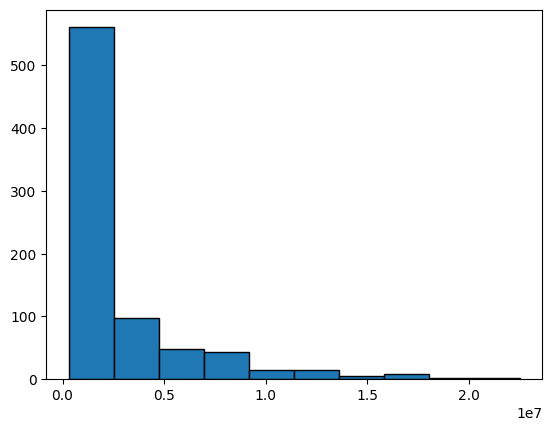

In [72]:
#histogram of the salaries
print(f'Salary distribution mean: {np.mean(baseball_salaries["salary"])}')
print(f'Salary distribution desviation: {np.std(baseball_salaries["salary"])}')

plt.hist(baseball_salaries['salary'], edgecolor = 'black', alpha = 1.0)



### Taking Samples

Pandas DataFrame has built-in methods for taking random samples with replacement.  The `.sample()` method is demonstrated below.

In [6]:
baseball_salaries['salary'].sample(4)

,salary
121,500000
302,320000
195,6000000
391,9000000


### Sample Means

Now, use this method to repeatedly take samples and build a list of sample means.  As a starting place let us take 1000 samples of size 5 and draw the histogram of the sample means.  What is the mean and standard deviation?

In [103]:
from numpy.random.mtrand import sample
#empty list for sample means
sample_means5 = []
sample_means10 = []
sample_means25 = []
sample_means50 = []
sample_means100 = []

for i in range(1000):
  sample_means5.append(baseball_salaries['salary'].sample(5).mean())
  sample_means10.append(baseball_salaries['salary'].sample(10).mean())
  sample_means25.append(baseball_salaries['salary'].sample(25).mean())
  sample_means50.append(baseball_salaries['salary'].sample(50).mean())
  sample_means100.append(baseball_salaries['salary'].sample(100).mean())

data = {
    'size' : ['n=5', 'n=10', 'n=25', 'n=50', 'n=00'],
    'mean': [np.mean(sample_means5), np.mean(sample_means10), np.mean(sample_means25), np.mean(sample_means50), np.mean(sample_means100)],
    'std': [np.std(sample_means5), np.std(sample_means10), np.std(sample_means25), np.std(sample_means50), np.std(sample_means100)]
}

pd.options.display.float_format = "{:,.3f}".format

df = pd.DataFrame(data=data)

pprint(df)




   size          mean           std
0   n=5 2,445,377.286 1,566,102.735
1  n=10 2,514,064.508 1,087,638.778
2  n=25 2,539,148.175   706,786.595
3  n=50 2,530,680.829   495,316.920
4  n=00 2,512,478.973   317,726.468


Text(0.5, 1.0, 'n = 5')

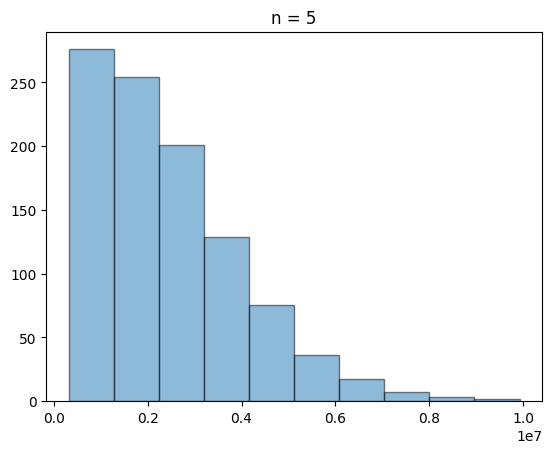

In [112]:
#histogram of sample means
plt.hist(sample_means5, edgecolor = 'black', alpha = 0.5)
plt.title('n = 5')



Text(0.5, 1.0, 'n = 10')

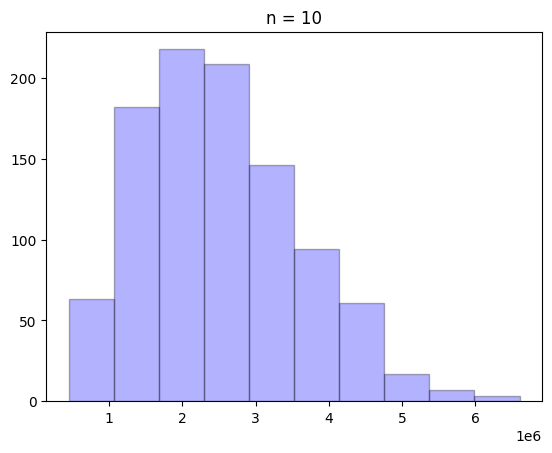

In [113]:
plt.hist(sample_means10, edgecolor = 'black', alpha = 0.3, color='blue')
plt.title('n = 10')


Text(0.5, 1.0, 'n=25')

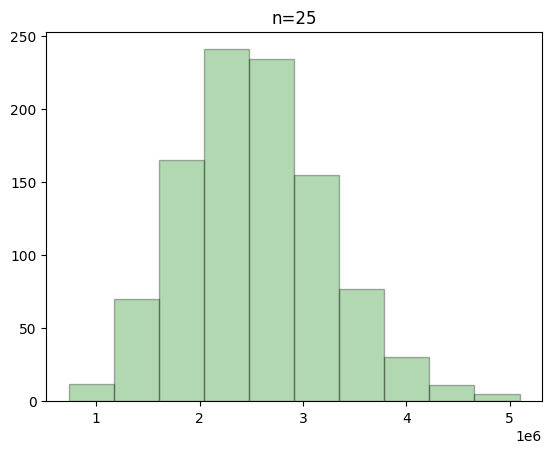

In [109]:
plt.hist(sample_means25, edgecolor = 'black', alpha = 0.3, color='green')
plt.title('n=25')


Text(0.5, 1.0, 'n=50')

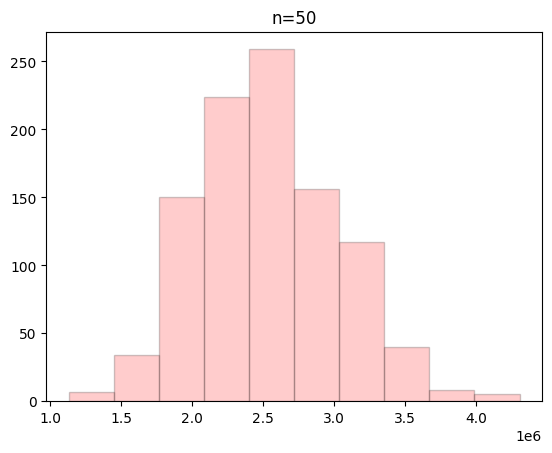

In [111]:
plt.hist(sample_means50, edgecolor = 'black', alpha = 0.2, color='red')
plt.title('n=50')


Text(0.5, 1.0, 'n=100')

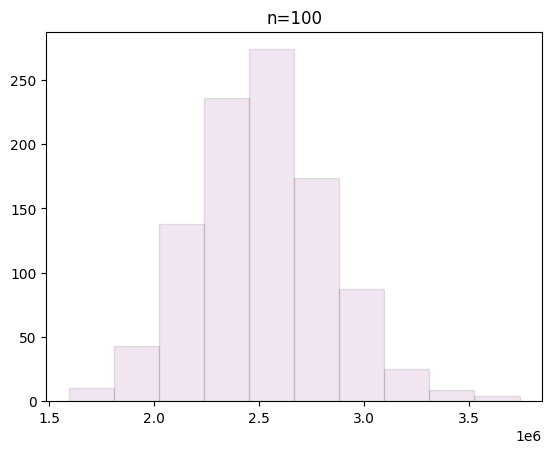

In [110]:
plt.hist(sample_means100, edgecolor = 'black', alpha = 0.1, color='purple')
plt.title('n=100')


Repeat the above exercise with samples of size:

- 10
- 25
- 50
- 100

Your discussion post should explain how the distribution of these sample means changes as the sample size changes, and how the mean and standard deviation of the distributions change.